In [1]:
%load_ext autoreload

from dotenv import load_dotenv

# Load environment variables from .env file
load_dotenv("../.env")

True

In [2]:
%autoreload 2

In [61]:
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import rasterio

from estuary.util.img import true_color

In [16]:
BASE = Path("/Volumes/x10pro/tanager_challenge/")

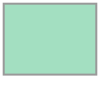

In [24]:
grid = gpd.read_file(BASE / "malibu_large.geojson")
grid.union_all()

In [22]:
t_sr_paths = sorted(list((BASE / "sat_data/tanager/sr/").iterdir()))
t_rgb_paths = sorted(list((BASE / "sat_data/tanager/rgb/").iterdir()))
[p.stem.split("_4001_ortho_sr_hdf5")[0] for p in t_sr_paths]

['20241215_185916_33',
 '20250123_185518_92',
 '20250726_192422_87',
 '20250920_193207_61']

In [29]:
from pathlib import Path

import geopandas as gpd
import rioxarray


def crop_tif(tif_path: Path, roi: gpd.GeoDataFrame, out_tif: Path) -> None:
    da = rioxarray.open_rasterio(tif_path, masked=True)
    roi = roi.to_crs(da.rio.crs)

    clipped = da.rio.clip(roi.geometry, roi.crs, drop=True)

    # Fill masked pixels with 0 for visual products
    clipped = clipped.fillna(0)

    # Preserve integer dtype if desired
    clipped = clipped.astype("uint8")
    clipped.rio.write_nodata(0, inplace=True)

    clipped.rio.to_raster(out_tif, driver="GTiff")

    print(f"Saved: {out_tif}")


for p in t_rgb_paths:
    out = p.parent.parent / "rgb_crop" / p.name
    out.parent.mkdir(exist_ok=True, parents=True)
    crop_tif(p, grid, out)

Saved: /Volumes/x10pro/tanager_challenge/sat_data/tanager/rgb_crop/20241215_185916_33_4001_ortho_visual.tif
Saved: /Volumes/x10pro/tanager_challenge/sat_data/tanager/rgb_crop/20250123_185518_92_4001_ortho_visual.tif
Saved: /Volumes/x10pro/tanager_challenge/sat_data/tanager/rgb_crop/20250726_192422_87_4001_ortho_visual.tif
Saved: /Volumes/x10pro/tanager_challenge/sat_data/tanager/rgb_crop/20250920_193207_61_4001_ortho_visual.tif


In [30]:
import h5py

h5_path = t_sr_paths[0]


def show_h5(name, obj):
    shape = getattr(obj, "shape", None)
    dtype = getattr(obj, "dtype", None)
    print(name, type(obj).__name__, shape, dtype)


with h5py.File(h5_path, "r") as f:
    f.visititems(show_h5)

HDFEOS Group None None
HDFEOS/ADDITIONAL Group None None
HDFEOS/ADDITIONAL/FILE_ATTRIBUTES Group None None
HDFEOS/GRIDS Group None None
HDFEOS/GRIDS/HYP Group None None
HDFEOS/GRIDS/HYP/Data Fields Group None None
HDFEOS/GRIDS/HYP/Data Fields/aerosol_optical_depth Dataset (713, 791) float32
HDFEOS/GRIDS/HYP/Data Fields/beta_cirrus_mask Dataset (713, 791) uint8
HDFEOS/GRIDS/HYP/Data Fields/beta_cloud_mask Dataset (713, 791) uint8
HDFEOS/GRIDS/HYP/Data Fields/column_water_vapour Dataset (713, 791) float32
HDFEOS/GRIDS/HYP/Data Fields/nodata_pixels Dataset (713, 791) uint8
HDFEOS/GRIDS/HYP/Data Fields/sensor_azimuth Dataset (713, 791) float32
HDFEOS/GRIDS/HYP/Data Fields/sensor_to_ground_path_length Dataset (713, 791) float32
HDFEOS/GRIDS/HYP/Data Fields/sensor_zenith Dataset (713, 791) float32
HDFEOS/GRIDS/HYP/Data Fields/sun_azimuth Dataset (713, 791) float32
HDFEOS/GRIDS/HYP/Data Fields/sun_zenith Dataset (713, 791) float32
HDFEOS/GRIDS/HYP/Data Fields/surface_reflectance Dataset (426,

In [37]:
import re
from pathlib import Path

import geopandas as gpd
import h5py
import xarray as xr
from affine import Affine


def parse_struct_metadata(meta_text: str):
    # These patterns usually work for HDF-EOS grid metadata
    ul_match = re.search(r"UpperLeftPointMtrs=\(([-0-9.eE]+),([-0-9.eE]+)\)", meta_text)
    lr_match = re.search(r"LowerRightMtrs=\(([-0-9.eE]+),([-0-9.eE]+)\)", meta_text)
    xdim_match = re.search(r"XDim=(\d+)", meta_text)
    ydim_match = re.search(r"YDim=(\d+)", meta_text)
    proj_match = re.search(r"Projection=(\w+)", meta_text)

    if ul_match is None or lr_match is None or xdim_match is None or ydim_match is None:
        raise ValueError("Could not parse StructMetadata.0")

    ulx, uly = map(float, ul_match.groups())
    lrx, lry = map(float, lr_match.groups())
    xdim = int(xdim_match.group(1))
    ydim = int(ydim_match.group(1))
    proj = proj_match.group(1) if proj_match else None

    return {
        "ulx": ulx,
        "uly": uly,
        "lrx": lrx,
        "lry": lry,
        "xdim": xdim,
        "ydim": ydim,
        "projection": proj,
    }


def tanager_h5_to_dataarray(h5_path: Path, dataset_key: str) -> xr.DataArray:
    with h5py.File(h5_path, "r") as f:
        cube = f[dataset_key][:]  # (band, y, x)

        meta_raw = f["HDFEOS INFORMATION/StructMetadata.0"][()]
        if isinstance(meta_raw, bytes):
            meta_text = meta_raw.decode("utf-8")
        else:
            meta_text = meta_raw.astype(str)

        meta = parse_struct_metadata(meta_text)

    if cube.shape[1] != meta["ydim"] or cube.shape[2] != meta["xdim"]:
        raise ValueError(
            f"Cube shape {cube.shape} does not match metadata dims {(meta['ydim'], meta['xdim'])}"
        )

    ulx, uly = meta["ulx"], meta["uly"]
    lrx, lry = meta["lrx"], meta["lry"]
    xdim, ydim = meta["xdim"], meta["ydim"]

    xres = (lrx - ulx) / xdim
    yres = (lry - uly) / ydim

    # Pixel-center coordinates
    x = ulx + xres * (0.5 + np.arange(xdim))
    y = uly + yres * (0.5 + np.arange(ydim))

    da = xr.DataArray(
        cube,
        dims=("band", "y", "x"),
        coords={
            "band": np.arange(cube.shape[0]),
            "y": y,
            "x": x,
        },
        name="surface_reflectance",
    )

    transform = Affine.translation(ulx, uly) * Affine.scale(xres, yres)

    da = da.rio.write_transform(transform)
    return da


def crop_tanager_h5(
    h5_path: Path,
    roi: gpd.GeoDataFrame,
    out_tif: Path,
    dataset_key: str = "HDFEOS/GRIDS/HYP/Data Fields/surface_reflectance",
    crs: str = "EPSG:32611",  # likely for Malibu, but verify
) -> None:
    da = tanager_h5_to_dataarray(h5_path, dataset_key)

    da = da.astype("float32")
    da = da.rio.write_crs(crs)

    roi = roi.to_crs(da.rio.crs)

    clipped = da.rio.clip(roi.geometry, roi.crs, drop=True)
    clipped.rio.to_raster(out_tif, driver="GTiff")

    print(f"Saved: {out_tif}")


for pth in t_sr_paths:
    out = pth.parent.parent / "sr_clipped" / (pth.stem + ".tiff")
    out.parent.mkdir(exist_ok=True, parents=True)

    crop_tanager_h5(
        h5_path=pth,
        roi=grid,
        out_tif=out,
    )

Saved: /Volumes/x10pro/tanager_challenge/sat_data/tanager/sr_clipped/20241215_185916_33_4001_ortho_sr_hdf5.tiff
Saved: /Volumes/x10pro/tanager_challenge/sat_data/tanager/sr_clipped/20250123_185518_92_4001_ortho_sr_hdf5.tiff
Saved: /Volumes/x10pro/tanager_challenge/sat_data/tanager/sr_clipped/20250726_192422_87_4001_ortho_sr_hdf5.tiff
Saved: /Volumes/x10pro/tanager_challenge/sat_data/tanager/sr_clipped/20250920_193207_61_4001_ortho_sr_hdf5.tiff


In [52]:
with rasterio.open(ss_paths[0]) as src:
    print(src.count)

4


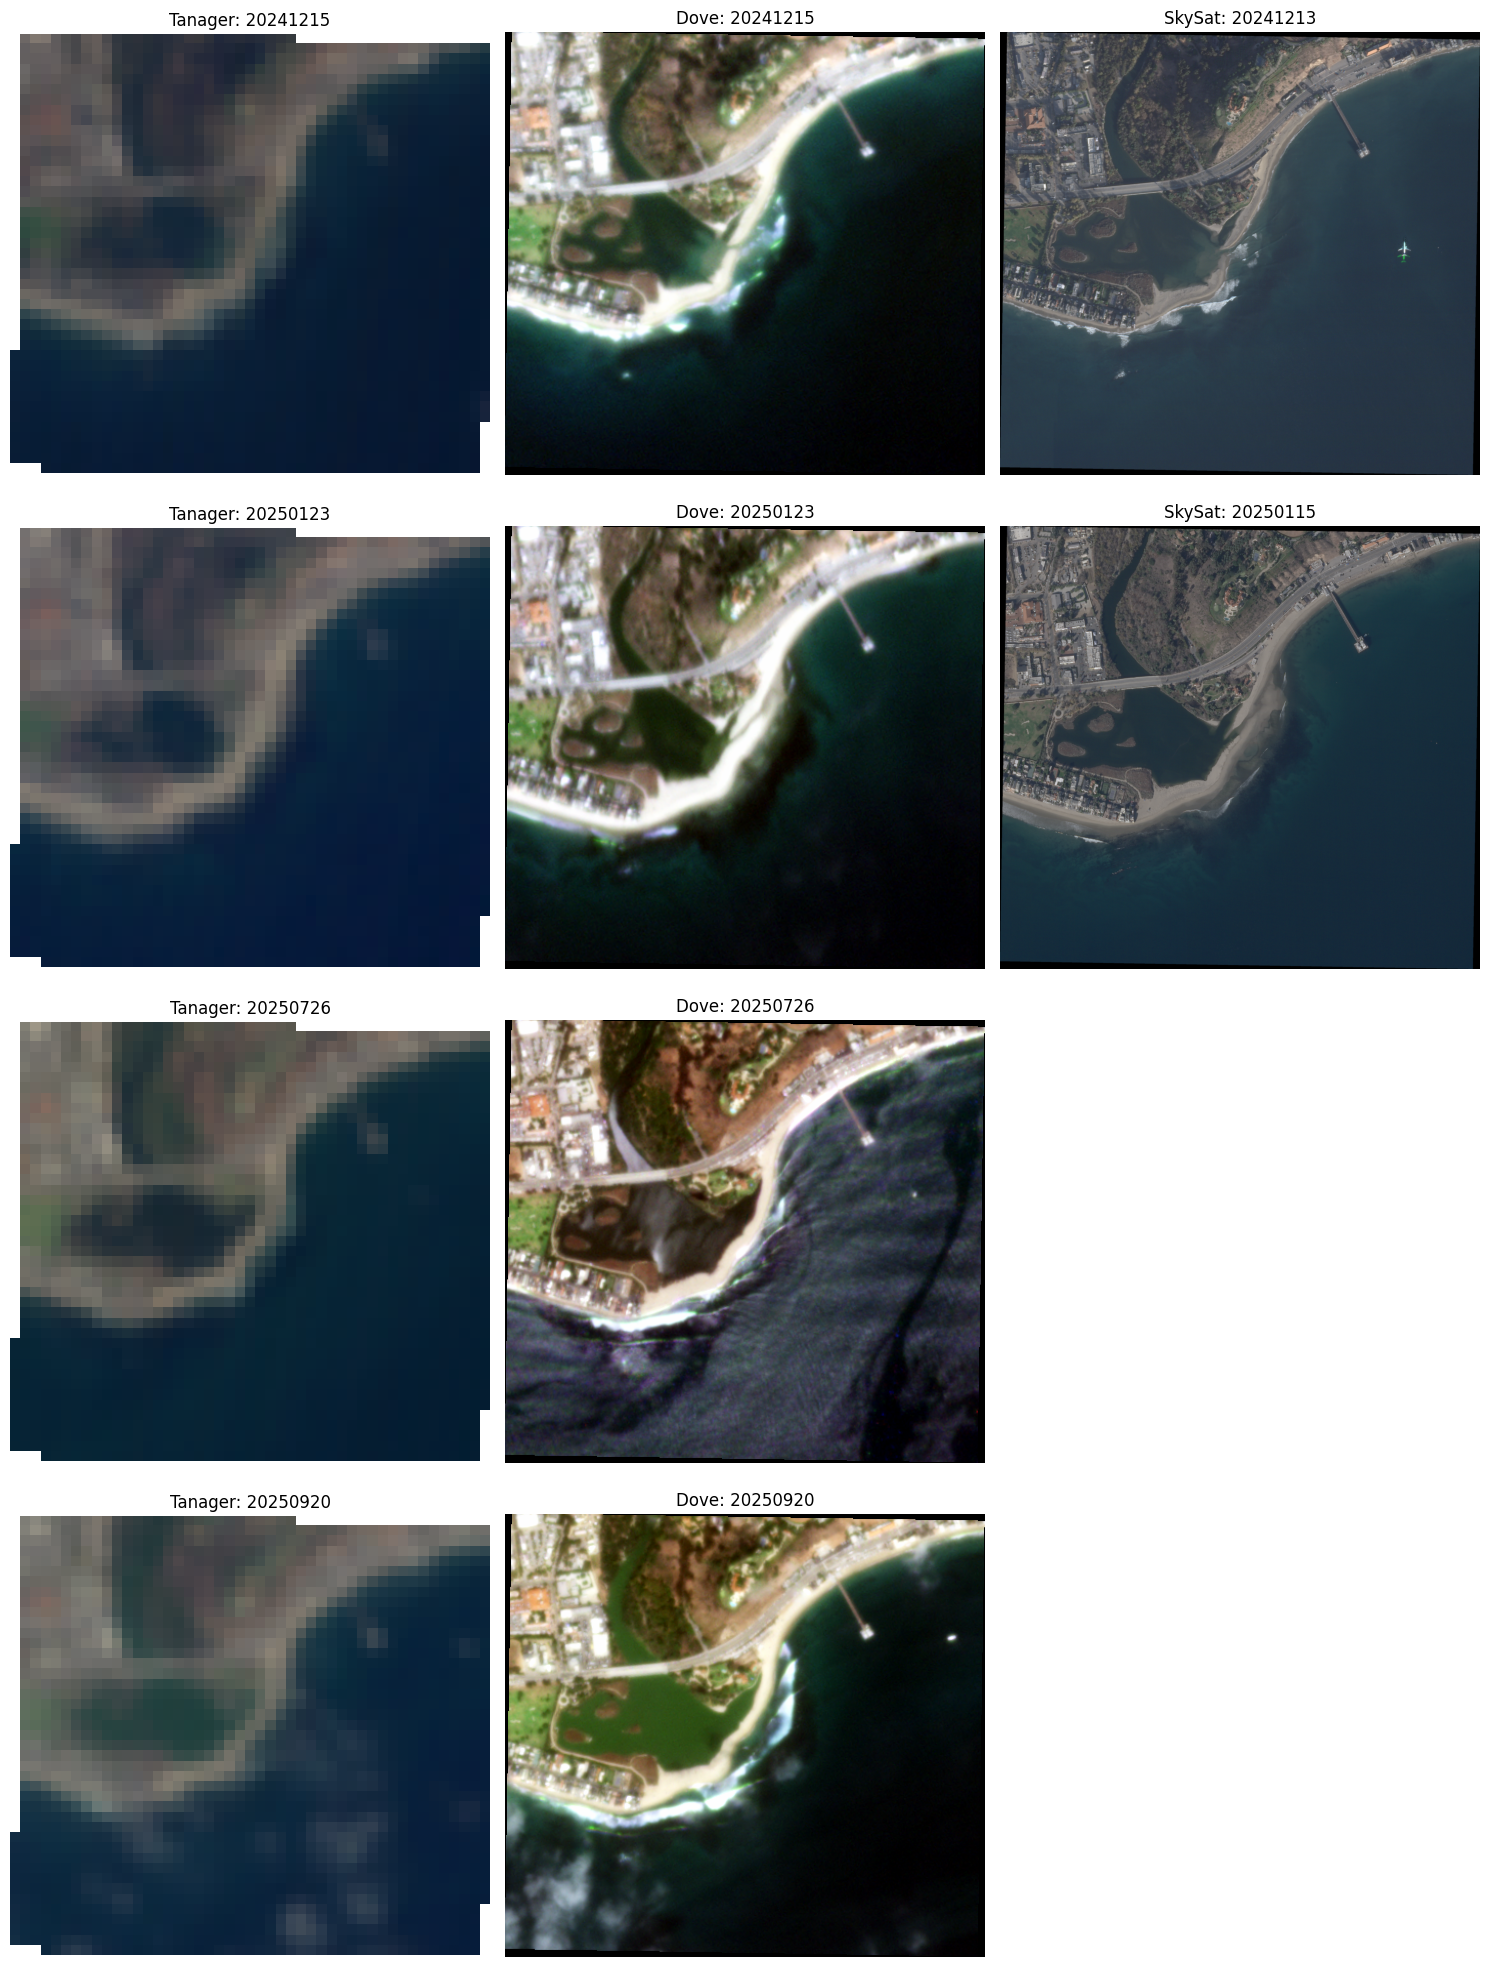

In [65]:
fig, axes = plt.subplots(ncols=3, nrows=4, figsize=(15, 20))

ss_vis_paths = sorted(list((BASE / "sat_data/skysat").glob("*_visual_clip.tif")))
assert False
ss_paths = sorted(list((BASE / "sat_data/skysat").glob("*_visual_clip.tif")))
ss_vis_paths = ss_vis_paths + [None, None]
dove_paths = sorted(list((BASE / "sat_data/dove").glob("*SR_8b_clip.tif")))
c_rgb_paths = sorted(list((BASE / "sat_data/tanager/rgb_crop/").iterdir()))
c_sr_paths = sorted(list((BASE / "sat_data/tanager/sr_clipped/").iterdir()))

for ax in axes.flatten():
    ax.axis("off")

for i, (pth, ss_pth, d_pth) in enumerate(zip(c_rgb_paths, ss_vis_paths, dove_paths)):
    ax, ax1, ax2 = axes[i]

    with rasterio.open(pth) as src:
        data = src.read()
        data = data.transpose((1, 2, 0))
    ax.set_title("Tanager: " + pth.stem.split("_")[0])
    ax.imshow(data)

    with rasterio.open(d_pth) as src:
        data = src.read()
        nodata = src.read(1, masked=True).mask
    img = true_color(data, nodata)
    ax1.set_title("Dove: " + d_pth.stem.split("_")[0])
    ax1.imshow(img)

    if ss_pth is not None:
        with rasterio.open(ss_pth) as src:
            data = src.read()[:3].transpose((1, 2, 0))
        ax2.set_title("SkySat: " + ss_pth.stem.split("_")[0])
        ax2.imshow(data)

fig.tight_layout()
plt.show()

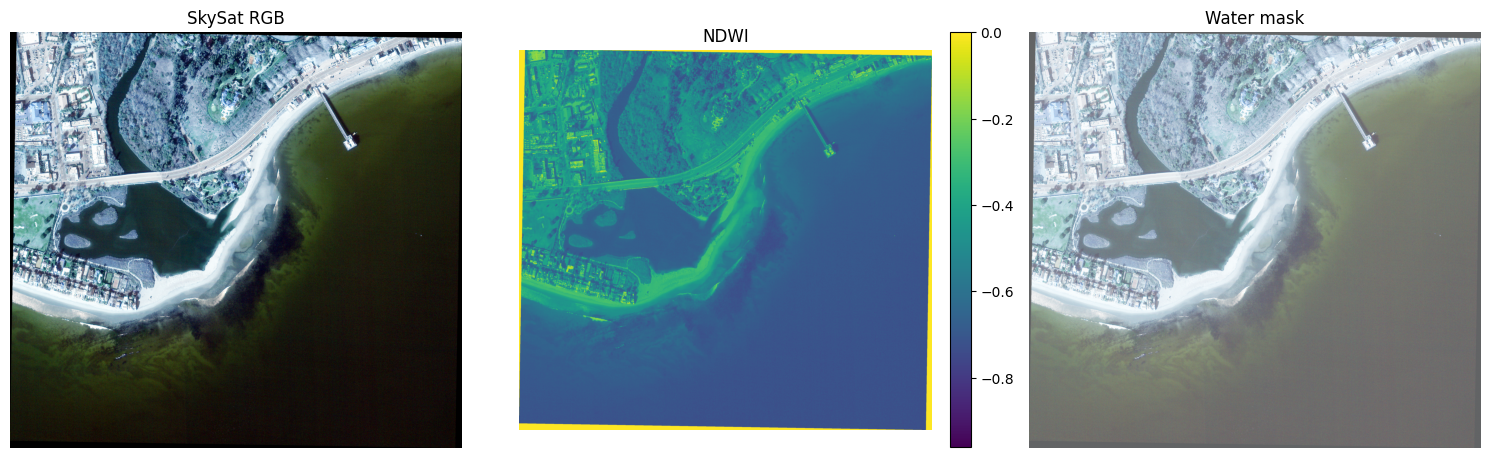

In [73]:
from pathlib import Path

import matplotlib.pyplot as plt
from scipy import ndimage as ndi


def load_skysat_sr(path):
    with rasterio.open(path) as src:
        data = src.read()
        nodata = src.read(1, masked=True).mask
    return data, nodata
    # da = rioxarray.open_rasterio(path, masked=True)
    # arr = da.values.astype("float32")
    # return da, arr


def compute_ndwi(arr):
    # Assumes band order: blue, green, red, nir
    green = arr[1]
    nir = arr[3]
    ndwi = (green - nir) / (green + nir + 1e-6)
    return ndwi


def clean_mask(mask, min_size=100, closing_size=3, opening_size=2, fill_holes=True):
    structure_close = np.ones((closing_size, closing_size), dtype=bool)
    structure_open = np.ones((opening_size, opening_size), dtype=bool)

    mask = ndi.binary_closing(mask, structure=structure_close)
    mask = ndi.binary_opening(mask, structure=structure_open)

    if fill_holes:
        mask = ndi.binary_fill_holes(mask)

    labels, n = ndi.label(mask)
    if n > 0:
        sizes = ndi.sum(mask, labels, index=np.arange(1, n + 1))
        keep = np.zeros(n + 1, dtype=bool)
        keep[1:] = sizes >= min_size
        mask = keep[labels]

    return mask


def make_water_mask(arr, ndwi_thresh=0.05, nir_thresh=None):
    ndwi = compute_ndwi(arr)

    mask = ndwi > ndwi_thresh

    if nir_thresh is not None:
        nir = arr[3]
        mask = mask & (nir < nir_thresh)

    return ndwi, mask


skysat_path = ss_paths[1]

arr, nodata = load_skysat_sr(skysat_path)

ndwi, water_mask_raw = make_water_mask(arr.astype(np.float32), ndwi_thresh=0.05, nir_thresh=0.12)
water_mask = clean_mask(water_mask_raw, min_size=200, closing_size=3, opening_size=2)

# quick plot
rgb = true_color(arr, nodata)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(rgb)
axes[0].set_title("SkySat RGB")
axes[0].axis("off")

im = axes[1].imshow(ndwi, cmap="viridis")
axes[1].set_title("NDWI")
axes[1].axis("off")
plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)

axes[2].imshow(rgb)
axes[2].imshow(water_mask, cmap="Blues", alpha=0.4)
axes[2].set_title("Water mask")
axes[2].axis("off")

plt.tight_layout()
plt.show()

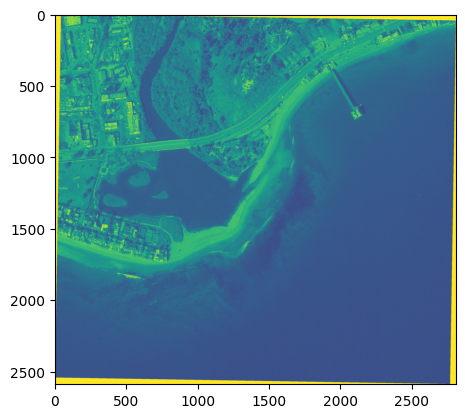

In [75]:
plt.figure()
plt.imshow(ndwi)

In [77]:
ndwi.max()

np.float32(0.0)